In [1]:
from __future__ import annotations

import functools, glob, json, logging, pickle, re, time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (
    adjusted_rand_score, calinski_harabasz_score,
    davies_bouldin_score, silhouette_samples, silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler

# Optional — kneedle elbow detection. Falls back to 2nd-derivative if missing.
try:
    from kneed import KneeLocator
    _HAS_KNEED = True
except ImportError:
    KneeLocator = None
    _HAS_KNEED = False

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [29]:
#Paths

PROJECT_ROOT  = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR      = PROJECT_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR    = PROJECT_ROOT / "models"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"

AGGREGATED_FILE     = "aggregated_zone_hour.parquet"
CLUSTER_LABELS_FILE = "cluster_labels.parquet"
SCALED_FILE         = "scaled_features.parquet"
VIZ_DATA_FILE       = "viz_data_precomputed.parquet"
MODEL_FILE          = "model.pkl"
SCALER_FILE         = "scaler.pkl"
METRICS_FILE        = "metrics.json"

#Cleaning thresholds

MIN_SPEED_MPH, MAX_SPEED_MPH = 1.0, 100.0
MIN_DISTANCE_MILES, MAX_DISTANCE_MILES = 0.01, 200.0
MIN_DURATION_SECONDS, MAX_DURATION_SECONDS = 30, 4 * 3600
MIN_ZONE_ID, MAX_ZONE_ID = 1, 263
TRIVIAL_SAME_ZONE_DISTANCE_MILES = 0.10
IQR_FENCE_K, IQR_MIN_TRIPS_PER_ZONE = 3.0, 200

#Cluster feature set (final design)

# zone_id removed (categorical → not Euclidean)
# hour_of_day replaced by cyclic (hour_sin, hour_cos)
# avg_speed_mph removed (already implicit in speed_deviation)
# trip_density log-transformed → log_trip_density
# is_weekend retained as binary
CLUSTER_FEATURES = ["hour_sin", "hour_cos", "is_weekend",
                    "speed_deviation", "log_trip_density"]

#KPI targets (set in the PRD)
TARGET_SILHOUETTE = 0.5
TARGET_CVINTRA    = 0.20

#K-Means hyper-parameters
K_RANGE              = (2, 11)        # sweep k = 2..10
DEFAULT_K            = 3
KMEANS_RANDOM_STATE  = 42
KMEANS_N_INIT        = 10
KMEANS_MAX_ITER      = 300
SILHOUETTE_SAMPLE_SIZE = 50_000
STABILITY_N_SEEDS, STABILITY_ARI_MIN = 5, 0.70
SCALER_TYPE = "standard"
USE_KNEED_ELBOW = True

#DBSCAN hyper-parameters
DBSCAN_EPS, DBSCAN_MIN_SAMPLES = 0.5, 10
DBSCAN_NOISE_WARN_FRACTION = 0.30

#Reference data
AIRPORT_ZONES = {1, 132, 138}     # EWR, JFK, LGA
CBD_ZONES = {4, 12, 13, 45, 48, 50, 68, 79, 87, 88, 90, 100, 107, 113, 114,
             125, 137, 140, 141, 142, 143, 144, 148, 151, 158, 161, 162, 163,
             164, 170, 186, 209, 211, 224, 229, 230, 231, 232, 233, 234, 246,
             249, 261, 262, 263}
RUSH_HOUR_MORNING = {7, 8, 9}
RUSH_HOUR_EVENING = {16, 17, 18, 19}
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print("Project root:", PROJECT_ROOT)
print("Cluster feature set:", CLUSTER_FEATURES)


Project root: C:\Users\klvkl\Documents\Traffic_congestion
Cluster feature set: ['hour_sin', 'hour_cos', 'is_weekend', 'speed_deviation', 'log_trip_density']


In [3]:
# ── Lightweight utilities (logger, parquet I/O, JSON I/O, timing decorator) ──

def get_logger(name: str, level: int = logging.INFO) -> logging.Logger:
    log = logging.getLogger(name)
    log.setLevel(level)
    if not log.handlers:
        h = logging.StreamHandler()
        h.setFormatter(logging.Formatter(
            "%(asctime)s [%(levelname)s] %(name)s :: %(message)s", "%H:%M:%S"))
        log.addHandler(h)
        log.propagate = False
    return log

def timeit(label=None):
    def deco(fn):
        tag = label or fn.__name__
        log = get_logger(fn.__module__ or "nb")
        @functools.wraps(fn)
        def wrap(*a, **k):
            t0 = time.perf_counter()
            try:    return fn(*a, **k)
            finally: log.info(f"⏱  {tag}: {time.perf_counter()-t0:.2f}s")
        return wrap
    return deco

def read_parquet_safe(path, label=None):
    if not Path(path).exists():
        raise FileNotFoundError(f"Required parquet missing: {path}")
    return pd.read_parquet(path)

def write_parquet(df, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False, engine="pyarrow")

def write_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def parse_year_month(filename):
    m = re.search(r"(\d{4}-\d{2})", Path(filename).stem)
    if not m:
        raise ValueError(f"Could not parse YYYY-MM from {filename!r}")
    return m.group(1)

logger = get_logger("notebook")
logger.info("Setup complete.")


10:49:07 [INFO] notebook :: Setup complete.


In [4]:
agg = pd.read_parquet(PROCESSED_DIR / AGGREGATED_FILE)
print(f"Aggregated shape: {agg.shape}")
print(f"Distinct zones:    {agg['zone_id'].nunique()}")
print(f"Hour-of-day range: {agg['hour_of_day'].min()}–{agg['hour_of_day'].max()}")
print(f"Columns:           {list(agg.columns)}")
agg.head()


Aggregated shape: (39413, 14)
Distinct zones:    260
Hour-of-day range: 0–23
Columns:           ['zone_id', 'hour_of_day', 'day_of_week', 'is_weekend', 'avg_speed_mph', 'trip_density', 'avg_trip_duration', 'speed_deviation', 'hour_sin', 'hour_cos', 'log_trip_density', 'is_airport', 'is_cbd', 'is_rush_hour']


,zone_id,hour_of_day,day_of_week,is_weekend,avg_speed_mph,trip_density,avg_trip_duration,speed_deviation,hour_sin,hour_cos,log_trip_density,is_airport,is_cbd,is_rush_hour
0,1,1,0,False,38.850876,2,1381.0,0.223484,0.258819,0.965926,1.098612,True,False,False
1,1,1,4,False,38.403908,1,1228.0,-0.223484,0.258819,0.965926,0.693147,True,False,False
2,1,2,1,False,31.958273,1,2013.0,0.000000,0.500000,0.866025,0.693147,True,False,False
3,1,5,3,False,36.465729,1,3633.0,9.312464,0.965926,0.258819,0.693147,True,False,False
4,1,5,4,False,9.599999,1,165.0,-17.553265,0.965926,0.258819,0.693147,True,False,False


In [5]:
# Quick descriptive summary
agg[["avg_speed_mph", "trip_density", "speed_deviation",
     "is_weekend", "log_trip_density"]].describe().round(2)


,avg_speed_mph,trip_density,speed_deviation,log_trip_density
count,39413.00,39413.00,39413.00,39413.00
mean,15.48,539.38,-0.00,4.00
std,5.65,1447.70,2.77,2.10
min,1.27,1.00,-28.44,0.69
25%,11.37,11.00,-1.26,2.48
50%,14.47,37.00,-0.23,3.64
75%,18.35,175.00,1.11,5.17
max,77.73,18799.00,40.66,9.84


In [30]:
#Filter primitives

def _filter(df, mask, rule_name):
    before = len(df)
    df = df[mask]
    dropped = before - len(df)
    if dropped:
        logger.debug(f"  {rule_name}: dropped {dropped:,} rows")
    return df


def cast_dtypes(df):
    df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
    df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
    df["trip_distance"]    = pd.to_numeric(df["trip_distance"], errors="coerce").astype("float32")
    df["trip_duration"]    = pd.to_numeric(df["trip_duration"], errors="coerce").astype("float32")
    df["PULocationID"]     = pd.to_numeric(df["PULocationID"],  errors="coerce").astype("Int32")
    df["DOLocationID"]     = pd.to_numeric(df["DOLocationID"],  errors="coerce").astype("Int32")
    if "fare_amount" in df.columns:
        df["fare_amount"]    = pd.to_numeric(df["fare_amount"], errors="coerce").astype("float32")
    if "passenger_count" in df.columns:
        df["passenger_count"] = pd.to_numeric(df["passenger_count"], errors="coerce").astype("Int16")
    return df


def remove_duplicates(df):
    subset = ["pickup_datetime", "dropoff_datetime",
              "PULocationID", "DOLocationID", "trip_distance"]
    return df.drop_duplicates(subset=subset)


def remove_nulls(df):
    critical = ["pickup_datetime", "dropoff_datetime", "trip_distance",
                "trip_duration", "PULocationID", "DOLocationID"]
    return df.dropna(subset=critical)


def remove_invalid_timestamps(df):
    return _filter(df, df["pickup_datetime"] < df["dropoff_datetime"],
                   "remove_invalid_timestamps")


def remove_wrong_month(df, expected_ym):
    try:
        expected = pd.Period(expected_ym, freq="M")
    except (ValueError, TypeError):
        return df
    mask = df["pickup_datetime"].dt.to_period("M") == expected
    return _filter(df, mask, f"remove_wrong_month (expected={expected_ym})")


def remove_invalid_distance(df):
    mask = df["trip_distance"].between(MIN_DISTANCE_MILES, MAX_DISTANCE_MILES)
    return _filter(df, mask, "remove_invalid_distance")


def remove_invalid_duration(df):
    mask = df["trip_duration"].between(MIN_DURATION_SECONDS, MAX_DURATION_SECONDS)
    return _filter(df, mask, "remove_invalid_duration")


def remove_speed_outliers(df):
    duration_hours = (df["trip_duration"] / 3600.0).replace(0, np.nan)
    speed = df["trip_distance"] / duration_hours
    mask  = speed.between(MIN_SPEED_MPH, MAX_SPEED_MPH)
    return _filter(df, mask, "remove_speed_outliers")


def remove_invalid_zones(df):
    mask = (df["PULocationID"].between(MIN_ZONE_ID, MAX_ZONE_ID)
            & df["DOLocationID"].between(MIN_ZONE_ID, MAX_ZONE_ID))
    return _filter(df, mask, "remove_invalid_zones")


def remove_trivial_same_zone_trips(df, max_distance=TRIVIAL_SAME_ZONE_DISTANCE_MILES):
    same_zone = df["PULocationID"] == df["DOLocationID"]
    near_zero = df["trip_distance"] <= max_distance
    keep = ~(same_zone & near_zero)
    return _filter(df, keep, f"remove_trivial_same_zone_trips (≤{max_distance} mi)")


def remove_invalid_quality_signals(df):
    masks = []
    if "fare_amount" in df.columns:
        masks.append(df["fare_amount"] >= 0)
    if "passenger_count" in df.columns:
        pc = df["passenger_count"]
        masks.append(pc.isna() | (pc.astype("Int64") > 0))
    if not masks:
        return df
    combined = masks[0]
    for m in masks[1:]:
        combined = combined & m
    return _filter(df, combined, "remove_invalid_quality_signals")


In [31]:
#Per-zone IQR fence on speed (opt-in, more principled than global caps)

def remove_iqr_speed_outliers_by_zone(df, k=IQR_FENCE_K,
                                      min_trips_per_zone=IQR_MIN_TRIPS_PER_ZONE):
    duration_hours = (df["trip_duration"] / 3600.0).replace(0, np.nan)
    speed = df["trip_distance"] / duration_hours

    grp = pd.DataFrame({"PULocationID": df["PULocationID"], "_speed": speed}) \
            .dropna(subset=["_speed"])
    counts = grp.groupby("PULocationID")["_speed"].size()
    eligible = counts[counts >= min_trips_per_zone].index
    if len(eligible) == 0:
        return df

    sub = grp[grp["PULocationID"].isin(eligible)]
    fences = (sub.groupby("PULocationID")["_speed"]
                 .quantile([0.25, 0.75])
                 .unstack()
                 .rename(columns={0.25: "q1", 0.75: "q3"}))
    fences["iqr"] = fences["q3"] - fences["q1"]
    fences["lower"] = fences["q1"] - k * fences["iqr"]
    fences["upper"] = fences["q3"] + k * fences["iqr"]

    bounds = (df[["PULocationID"]]
                .merge(fences[["lower", "upper"]], left_on="PULocationID",
                       right_index=True, how="left"))
    lower = bounds["lower"].fillna(-np.inf).values
    upper = bounds["upper"].fillna(np.inf).values
    keep = (speed.values >= lower) & (speed.values <= upper)
    keep = keep | speed.isna().values
    return _filter(df, pd.Series(keep, index=df.index),
                   f"remove_iqr_speed_outliers_by_zone (k={k})")


#Composite cleaner

def clean_dataframe(df, month_label="", expected_ym=None,
                    use_iqr_filter=False, use_quality_gate=True):
    initial = len(df)
    df = cast_dtypes(df)
    df = remove_duplicates(df)
    df = remove_nulls(df)
    df = remove_invalid_timestamps(df)
    if expected_ym:
        df = remove_wrong_month(df, expected_ym)
    df = remove_invalid_distance(df)
    df = remove_invalid_duration(df)
    df = remove_speed_outliers(df)
    df = remove_invalid_zones(df)
    df = remove_trivial_same_zone_trips(df)
    if use_quality_gate:
        df = remove_invalid_quality_signals(df)
    if use_iqr_filter:
        df = remove_iqr_speed_outliers_by_zone(df)
    print(f"  cleaning {month_label}: kept {len(df):,}/{initial:,} "
          f"({100*len(df)/initial:.1f}%)" if initial else "  (empty)")
    return df

print("Preprocessing functions defined.")


Preprocessing functions defined.


In [32]:
#Per-trip feature derivation

def add_time_features(df):
    dt = df["pickup_datetime"]
    df = df.copy()
    df["hour_of_day"] = dt.dt.hour.astype("int8")
    df["day_of_week"] = dt.dt.dayofweek.astype("int8")
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype("bool")
    df["month"]       = dt.dt.month.astype("int8")
    return df


def add_speed_feature(df):
    df = df.copy()
    hours = (df["trip_duration"] / 3600.0).replace(0, np.nan)
    df["speed_mph"] = (df["trip_distance"] / hours).astype("float32")
    return df


def add_zone_feature(df):
    df = df.copy()
    df["zone_id"] = df["PULocationID"].astype("int32")
    return df


#Aggregation to (zone, hour-of-day, day-of-week)

def aggregate_zone_hour(df):
    agg = (df.groupby(["zone_id", "hour_of_day", "day_of_week", "is_weekend"],
                      observed=True)
              .agg(avg_speed_mph=("speed_mph", "mean"),
                   trip_density=("speed_mph", "count"),
                   avg_trip_duration=("trip_duration", "mean"))
              .reset_index())
    agg["avg_speed_mph"]    = agg["avg_speed_mph"].astype("float32")
    agg["trip_density"]     = agg["trip_density"].astype("int32")
    agg["avg_trip_duration"]= agg["avg_trip_duration"].astype("float32")
    return agg


#The headline: speed_deviation

def compute_speed_deviation(agg):
    """
    speed_deviation(z, h) = avg_speed(z, h) − baseline(z, h),
    where baseline(z, h) is the (zone, hour-of-day) mean across all
    day-of-week buckets. A negative deviation = slower than baseline.
    """
    baseline = (agg.groupby(["zone_id", "hour_of_day"])["avg_speed_mph"]
                   .mean().rename("baseline_speed").reset_index())
    agg = agg.merge(baseline, on=["zone_id", "hour_of_day"], how="left")
    agg["speed_deviation"] = (agg["avg_speed_mph"] - agg["baseline_speed"]
                             ).astype("float32")
    return agg.drop(columns=["baseline_speed"])


def add_cyclic_hour(agg):
    """Encode hour_of_day as (sin, cos) so 23:00 ↔ 00:00 are adjacent."""
    angle = 2.0 * np.pi * agg["hour_of_day"].astype("float32") / 24.0
    agg = agg.copy()
    agg["hour_sin"] = np.sin(angle).astype("float32")
    agg["hour_cos"] = np.cos(angle).astype("float32")
    return agg


def add_log_density(agg):
    """log1p tames the heavy-tailed trip_density distribution."""
    agg = agg.copy()
    agg["log_trip_density"] = np.log1p(agg["trip_density"].astype("float32")
                                       ).astype("float32")
    return agg


def add_zone_attributes(agg):
    """Post-hoc zone tags used by the dashboard but NOT by the cluster model."""
    agg = agg.copy()
    agg["is_airport"]   = agg["zone_id"].isin(AIRPORT_ZONES)
    agg["is_cbd"]       = agg["zone_id"].isin(CBD_ZONES)
    rush = RUSH_HOUR_MORNING | RUSH_HOUR_EVENING
    agg["is_rush_hour"] = agg["hour_of_day"].isin(rush)
    return agg

print("Feature-engineering functions defined.")


Feature-engineering functions defined.


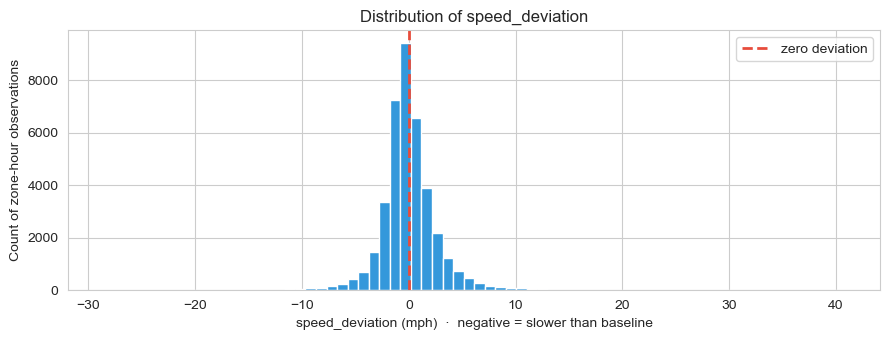

Δ range: [-28.44, 40.66] mph
Δ mean ± std: -0.00 ± 2.77


In [33]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(agg["speed_deviation"], bins=70, color="#3498db", edgecolor="white")
ax.axvline(0, color="#e74c3c", ls="--", lw=2, label="zero deviation")
ax.set_xlabel("speed_deviation (mph)  ·  negative = slower than baseline")
ax.set_ylabel("Count of zone-hour observations")
ax.set_title("Distribution of speed_deviation")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Δ range: [{agg['speed_deviation'].min():.2f}, {agg['speed_deviation'].max():.2f}] mph")
print(f"Δ mean ± std: {agg['speed_deviation'].mean():+.2f} ± {agg['speed_deviation'].std():.2f}")


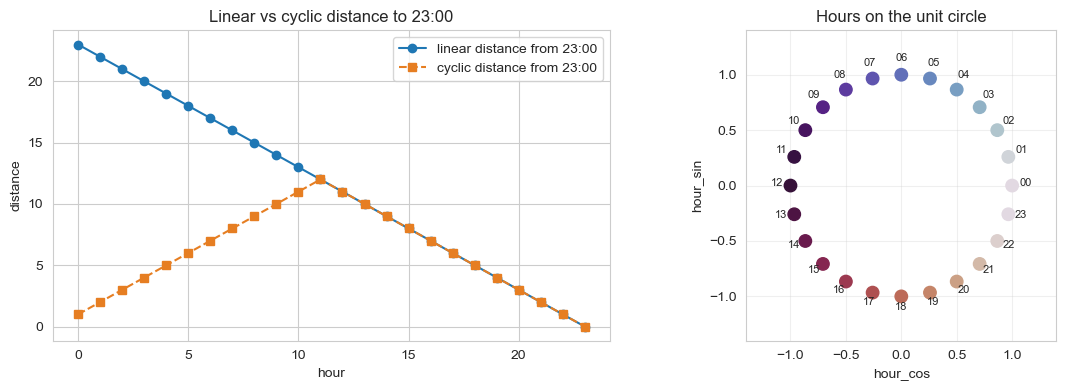

In [34]:
# Linear vs cyclic distance from h=23
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
hours = np.arange(24)
ax[0].plot(hours, [abs(h - 23) for h in hours], "o-", label="linear distance from 23:00")
ax[0].plot(hours, [min(abs(h - 23), 24 - abs(h - 23)) for h in hours],
           "s--", color="#e67e22", label="cyclic distance from 23:00")
ax[0].set_xlabel("hour"); ax[0].set_ylabel("distance"); ax[0].legend()
ax[0].set_title("Linear vs cyclic distance to 23:00")

# Hours on the unit circle
angles = 2 * np.pi * hours / 24
ax[1].scatter(np.cos(angles), np.sin(angles), c=hours, cmap="twilight", s=80)
for h, a in zip(hours, angles):
    ax[1].annotate(f"{h:02d}", (np.cos(a)*1.12, np.sin(a)*1.12),
                   ha="center", fontsize=8)
ax[1].set_xlim(-1.4, 1.4); ax[1].set_ylim(-1.4, 1.4)
ax[1].set_aspect("equal"); ax[1].grid(True, alpha=0.3)
ax[1].set_xlabel("hour_cos"); ax[1].set_ylabel("hour_sin")
ax[1].set_title("Hours on the unit circle")
plt.tight_layout(); plt.show()


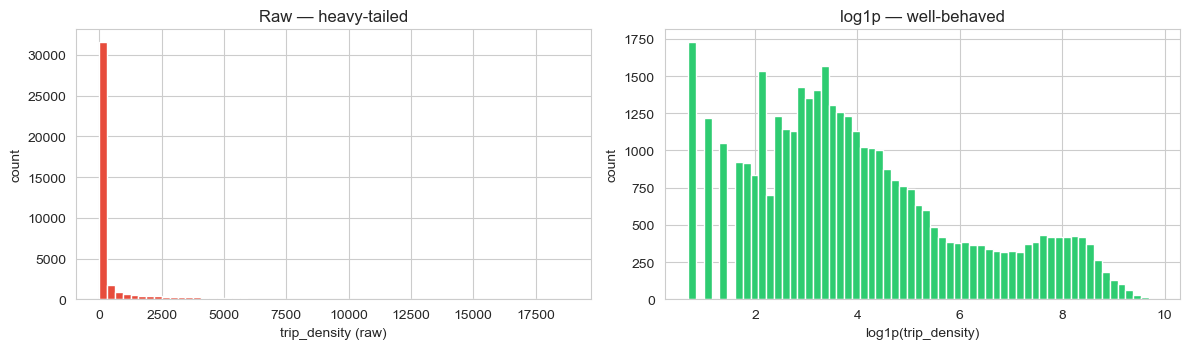

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(agg["trip_density"], bins=60, color="#e74c3c", edgecolor="white")
ax[0].set_xlabel("trip_density (raw)"); ax[0].set_ylabel("count")
ax[0].set_title("Raw — heavy-tailed")
ax[1].hist(np.log1p(agg["trip_density"]), bins=60, color="#2ecc71", edgecolor="white")
ax[1].set_xlabel("log1p(trip_density)"); ax[1].set_ylabel("count")
ax[1].set_title("log1p — well-behaved")
plt.tight_layout(); plt.show()


In [36]:
#Feature preparation & scaling

def prepare_features(df):
    """Return (X, df_clean) — feature matrix and the index-aligned dataframe."""
    missing = [c for c in CLUSTER_FEATURES if c not in df.columns]
    if missing:
        raise KeyError(f"Missing clustering features: {missing}")
    df_clean = df.dropna(subset=CLUSTER_FEATURES).reset_index(drop=True).copy()
    feat_df  = df_clean[CLUSTER_FEATURES].copy()
    for col in feat_df.columns:
        if feat_df[col].dtype == bool:
            feat_df[col] = feat_df[col].astype("int8")
    X = feat_df.values.astype("float64")
    print(f"Feature matrix: X.shape={X.shape}  features={CLUSTER_FEATURES}")
    return X, df_clean


def _make_scaler(kind=SCALER_TYPE):
    kind = (kind or "standard").lower()
    if kind == "robust":   return RobustScaler()
    if kind == "standard": return StandardScaler()
    raise ValueError(f"Unknown scaler: {kind!r}")


def scale_features(X, scaler_type=SCALER_TYPE):
    scaler = _make_scaler(scaler_type)
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


#Silhouette helper (samples large datasets for speed)

def _sample_for_silhouette(X_scaled, labels):
    n = len(X_scaled)
    if n > SILHOUETTE_SAMPLE_SIZE:
        idx = np.random.default_rng(42).choice(n, size=SILHOUETTE_SAMPLE_SIZE, replace=False)
        return X_scaled[idx], labels[idx]
    return X_scaled, labels


#k-selection

def _detect_elbow(ks, inertias):
    """Kneedle (preferred) → 2nd-derivative argmax (fallback)."""
    if USE_KNEED_ELBOW and _HAS_KNEED and len(ks) >= 3:
        try:
            kl = KneeLocator(ks, inertias, curve="convex",
                             direction="decreasing", interp_method="interp1d")
            if kl.knee is not None:
                return int(kl.knee), "kneed"
        except Exception:
            pass
    arr = np.asarray(inertias, dtype=float)
    if len(arr) >= 3:
        second_deriv = np.diff(arr, n=2)
        return int(ks[int(np.argmax(second_deriv)) + 1]), "2nd-derivative"
    return int(DEFAULT_K), "default-k"


def choose_k(X_scaled, k_range):
    ks = list(k_range)
    inertias, sils = [], []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE,
                    n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
        labels = km.fit_predict(X_scaled)
        inertias.append(float(km.inertia_))
        Xs, ls = _sample_for_silhouette(X_scaled, labels)
        sil = float(silhouette_score(Xs, ls)) if len(np.unique(ls)) > 1 else float("nan")
        sils.append(sil)

    elbow_k, elbow_src = _detect_elbow(ks, inertias)
    sil_arr = np.asarray(sils, dtype=float)
    sil_k = elbow_k if np.all(np.isnan(sil_arr)) else ks[int(np.nanargmax(sil_arr))]

    if abs(sil_k - elbow_k) <= 1:
        chosen, rule = elbow_k, f"elbow via {elbow_src} (silhouette agrees within 1)"
    else:
        chosen, rule = sil_k, f"silhouette-argmax (elbow via {elbow_src} disagreed)"
    print(f"k selection: elbow={elbow_k} ({elbow_src})  silhouette-argmax={sil_k}  → chosen={chosen}")
    print(f"  rule: {rule}")
    return chosen, {"ks": ks, "inertias": inertias, "silhouettes": sils,
                    "elbow_k": int(elbow_k), "elbow_source": elbow_src,
                    "silhouette_argmax_k": int(sil_k), "rule": rule}


In [37]:
#K-Means fitting and semantic relabelling

def train_kmeans(X_scaled, k):
    km = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE,
                n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
    km.fit(X_scaled)
    return km


def assign_semantic_labels(df, labels, k):
    """Re-label so congestion_level=0 is fastest, k-1 is slowest."""
    df = df.copy()
    df["raw_cluster"] = labels
    speed_by_cluster = (df.groupby("raw_cluster")["avg_speed_mph"]
                          .mean().sort_values(ascending=False))
    remap = {raw: lvl for lvl, raw in enumerate(speed_by_cluster.index)}
    df["congestion_level"] = df["raw_cluster"].map(remap).astype("int8")
    return df.drop(columns=["raw_cluster"])


#Evaluation

def compute_silhouette(X_scaled, labels):
    Xs, ls = _sample_for_silhouette(X_scaled, labels)
    if len(np.unique(ls)) < 2:
        return float("nan"), {}
    overall = float(silhouette_score(Xs, ls))
    samples = silhouette_samples(Xs, ls)
    per_cluster = {int(c): float(samples[ls == c].mean()) for c in np.unique(ls)}
    return overall, per_cluster


def compute_cvintra(df):
    """Intra-class CV of avg_speed_mph per cluster."""
    cv_map = {}
    for level, grp in df.groupby("congestion_level"):
        mean_s = float(grp["avg_speed_mph"].mean())
        std_s  = float(grp["avg_speed_mph"].std(ddof=0))
        cv_map[int(level)] = float(std_s / mean_s) if mean_s > 0 else float("nan")
    return cv_map


def stability_analysis(X_scaled, k, n_seeds=STABILITY_N_SEEDS):
    """Pairwise ARI across n_seeds random initialisations."""
    labels_list = []
    for seed in range(n_seeds):
        km = KMeans(n_clusters=k, random_state=seed,
                    n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
        labels_list.append(km.fit_predict(X_scaled))
    aris = [float(adjusted_rand_score(labels_list[i], labels_list[j]))
            for i in range(n_seeds) for j in range(i+1, n_seeds)]
    if not aris:
        return {"ari_mean": float("nan"), "ari_min": float("nan"), "ari_pass": False}
    return {"ari_mean": float(np.mean(aris)),
            "ari_min":  float(np.min(aris)),
            "ari_pass": bool(np.min(aris) >= STABILITY_ARI_MIN)}


def evaluate_clustering(X_scaled, df_labeled, k):
    labels = df_labeled["congestion_level"].values
    sil, sil_per = compute_silhouette(X_scaled, labels)
    db = float(davies_bouldin_score(X_scaled, labels))
    ch = float(calinski_harabasz_score(X_scaled, labels))
    cv_map = compute_cvintra(df_labeled)
    stab = stability_analysis(X_scaled, k)
    sizes = df_labeled["congestion_level"].value_counts().sort_index().to_dict()
    sizes = {int(k_): int(v) for k_, v in sizes.items()}
    centroids = (df_labeled.groupby("congestion_level")
                          [CLUSTER_FEATURES + ["avg_speed_mph", "trip_density"]]
                          .mean().round(3).to_dict(orient="index"))
    sil_pass = (sil == sil) and (sil > TARGET_SILHOUETTE)
    cv_pass  = all((cv == cv) and (cv < TARGET_CVINTRA) for cv in cv_map.values())
    return {
        "k": int(k), "features": list(CLUSTER_FEATURES),
        "silhouette_score": sil,
        "silhouette_per_cluster": {int(k_): float(v) for k_, v in sil_per.items()},
        "davies_bouldin": db, "calinski_harabasz": ch,
        "cvintra_by_level": cv_map, "cluster_sizes": sizes,
        "stability": stab,
        "centroid_means": {int(k_): v for k_, v in centroids.items()},
        "kpi_pass": bool(sil_pass and cv_pass),
        "timestamp": datetime.now(timezone.utc).isoformat(),
    }


In [14]:
# 1. Feature matrix
X, df_feat = prepare_features(agg)

# 2. Scale
X_scaled, scaler = scale_features(X, scaler_type=SCALER_TYPE)
print(f"Scaler: {type(scaler).__name__}")
print(f"Scaled mean: {X_scaled.mean(axis=0).round(3)}")
print(f"Scaled std:  {X_scaled.std(axis=0).round(3)}")


Feature matrix: X.shape=(39413, 5)  features=['hour_sin', 'hour_cos', 'is_weekend', 'speed_deviation', 'log_trip_density']
Scaler: StandardScaler
Scaled mean: [ 0.  0.  0. -0.  0.]
Scaled std:  [1. 1. 1. 1. 1.]


In [38]:
# 3. Joint elbow + silhouette sweep across K_RANGE
chosen_k, sweep = choose_k(X_scaled, range(*K_RANGE))
sweep_df = pd.DataFrame({"k": sweep["ks"],
                         "inertia": sweep["inertias"],
                         "silhouette": sweep["silhouettes"]})
sweep_df.style.format({"inertia": "{:,.0f}", "silhouette": "{:.4f}"})


k selection: elbow=3 (2nd-derivative)  silhouette-argmax=9  → chosen=9
  rule: silhouette-argmax (elbow via 2nd-derivative disagreed)


,k,inertia,silhouette
0,2,"154,435",0.2703
1,3,"129,678",0.2369
2,4,"113,666",0.2291
3,5,"100,858",0.2418
4,6,"89,112",0.2682
5,7,"81,074",0.2748
6,8,"74,201",0.2820
7,9,"68,369",0.2878
8,10,"62,660",0.2784


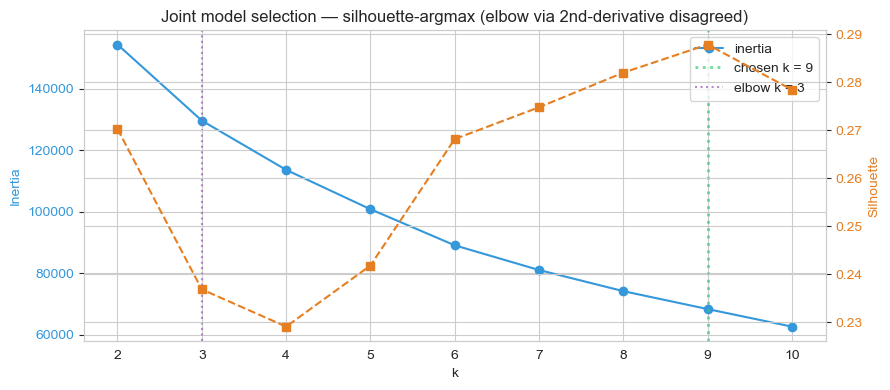

In [39]:
# Plot the sweep — inertia + silhouette on shared x
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sweep["ks"], sweep["inertias"], "o-", color="#3498db", label="inertia")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia", color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")

ax2 = ax1.twinx()
ax2.plot(sweep["ks"], sweep["silhouettes"], "s--", color="#e67e22", label="silhouette")
ax2.set_ylabel("Silhouette", color="#e67e22")
ax2.tick_params(axis="y", labelcolor="#e67e22")

ax1.axvline(chosen_k, color="#2ecc71", ls=":", lw=2, alpha=0.7,
            label=f"chosen k = {chosen_k}")
ax1.axvline(sweep["elbow_k"], color="#9b59b6", ls=":", lw=1.5, alpha=0.7,
            label=f"elbow k = {sweep['elbow_k']}")
ax1.legend(loc="upper right")
plt.title(f"Joint model selection — {sweep['rule']}")
plt.tight_layout(); plt.show()


In [40]:
# 4. Fit K-Means at the chosen k and assign semantic labels
km = train_kmeans(X_scaled, k=chosen_k)
df_labeled = assign_semantic_labels(df_feat, km.labels_, k=chosen_k)
print(f"K-Means fit: k={chosen_k}, inertia={km.inertia_:.1f}, n_iter={km.n_iter_}")
print(df_labeled["congestion_level"].value_counts().sort_index())


K-Means fit: k=9, inertia=68369.3, n_iter=45
congestion_level
0    1264
1    7224
2    3123
3    3965
4    1696
5    7584
6    3784
7    7005
8    3768
Name: count, dtype: int64


In [41]:
# 5. Evaluate — silhouette, DB, CH, CVintra, ARI stability, centroids
metrics = evaluate_clustering(X_scaled, df_labeled, k=chosen_k)
print(f"Silhouette        : {metrics['silhouette_score']:+.4f}  (target > {TARGET_SILHOUETTE})")
print(f"Davies–Bouldin    : {metrics['davies_bouldin']:.4f}   (lower better)")
print(f"Calinski–Harabasz : {metrics['calinski_harabasz']:,.0f}  (higher better)")
print(f"ARI stability     : min={metrics['stability']['ari_min']:.4f}  "
      f"mean={metrics['stability']['ari_mean']:.4f}")
print(f"Cluster sizes     : {metrics['cluster_sizes']}")


Silhouette        : +0.2878  (target > 0.5)
Davies–Bouldin    : 1.1272   (lower better)
Calinski–Harabasz : 9,272  (higher better)
ARI stability     : min=0.9368  mean=0.9676
Cluster sizes     : {0: 1264, 1: 7224, 2: 3123, 3: 3965, 4: 1696, 5: 7584, 6: 3784, 7: 7005, 8: 3768}


In [42]:
scorecard = pd.DataFrame([
    {"Metric": "Silhouette",                  "Target": "> 0.50",        "Observed": f"{metrics['silhouette_score']:.3f}"},
    {"Metric": "Davies–Bouldin",              "Target": "< 1.00",        "Observed": f"{metrics['davies_bouldin']:.3f}"},
    {"Metric": "Calinski–Harabasz",           "Target": "higher better", "Observed": f"{metrics['calinski_harabasz']:,.0f}"},
    {"Metric": "ARI seed stability (min)",    "Target": "≥ 0.80",        "Observed": f"{metrics['stability']['ari_min']:.3f}"},
    {"Metric": "ARI seed stability (mean)",   "Target": "≥ 0.90",        "Observed": f"{metrics['stability']['ari_mean']:.3f}"},
    {"Metric": "Stability gate",              "Target": "PASS",          "Observed": "PASS" if metrics['stability']['ari_pass'] else "FAIL"},
])
scorecard


,Metric,Target,Observed
0,Silhouette,> 0.50,0.288
1,Davies–Bouldin,< 1.00,1.127
2,Calinski–Harabasz,higher better,"9,272"
3,ARI seed stability (min),≥ 0.80,0.937
4,ARI seed stability (mean),≥ 0.90,0.968
5,Stability gate,PASS,PASS


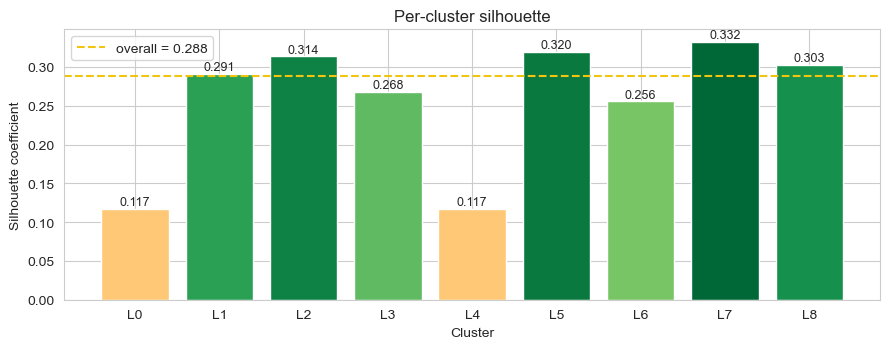

In [43]:
# Per-cluster silhouette
per_c = pd.Series(metrics["silhouette_per_cluster"]).sort_index()
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar([f"L{k_}" for k_ in per_c.index], per_c.values,
              color=plt.cm.RdYlGn(per_c.values / max(per_c.values.max(), 1e-9)))
ax.axhline(metrics["silhouette_score"], color="#f1c40f", ls="--",
           label=f"overall = {metrics['silhouette_score']:.3f}")
ax.set_xlabel("Cluster"); ax.set_ylabel("Silhouette coefficient")
ax.set_title("Per-cluster silhouette")
ax.legend()
for b, v in zip(bars, per_c.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


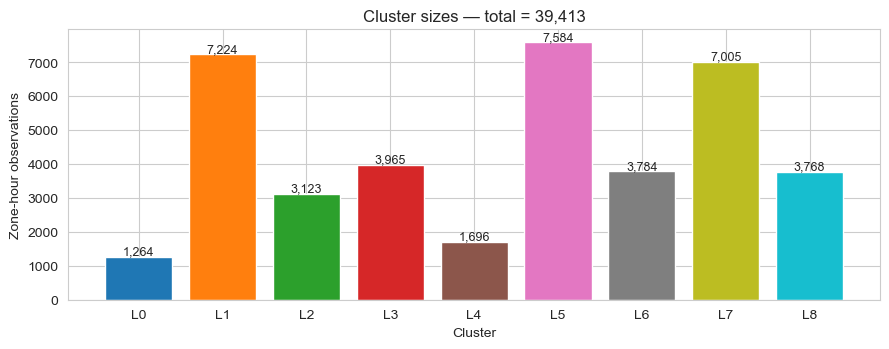

In [44]:
# Cluster sizes
sizes = pd.Series({int(k_): v for k_, v in metrics["cluster_sizes"].items()}).sort_index()
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar([f"L{k_}" for k_ in sizes.index], sizes.values,
       color=plt.cm.tab10(np.linspace(0, 1, len(sizes))))
ax.set_xlabel("Cluster"); ax.set_ylabel("Zone-hour observations")
ax.set_title(f"Cluster sizes — total = {sizes.sum():,}")
for i, v in enumerate(sizes.values):
    ax.text(i, v + max(sizes.values) * 0.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


In [45]:
# Cluster centroids in feature space
centroids = pd.DataFrame(metrics["centroid_means"]).T
centroids.index = [f"L{i}" for i in centroids.index]
centroids.round(3)


,hour_sin,hour_cos,is_weekend,speed_deviation,log_trip_density,avg_speed_mph,trip_density
L0,0.233,0.308,0.238,7.876,1.404,29.552,6.963
L1,-0.070,0.819,0.000,0.244,3.325,18.315,85.767
L2,0.747,-0.407,1.000,2.882,3.984,18.069,264.863
L3,-0.054,0.785,1.000,-0.416,4.403,17.594,602.633
L4,0.229,0.328,0.143,-6.203,1.376,15.273,3.970
L5,0.791,-0.327,0.000,-1.071,4.138,14.456,231.152
L6,-0.641,-0.514,1.000,1.247,4.592,13.653,786.040
L7,-0.617,-0.544,0.000,-0.541,3.090,12.535,39.754
L8,-0.471,-0.213,0.002,-0.359,7.763,10.443,3291.105


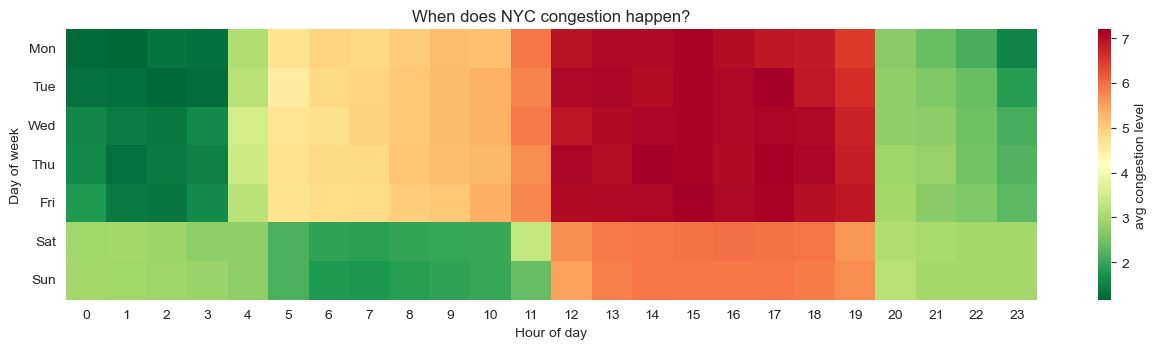

In [46]:
# Day × hour heatmap of average congestion level
heat = (df_labeled.groupby(["day_of_week", "hour_of_day"])["congestion_level"]
                  .mean().unstack(fill_value=np.nan))
fig, ax = plt.subplots(figsize=(13, 3.6))
sns.heatmap(heat, cmap="RdYlGn_r", ax=ax,
            cbar_kws={"label": "avg congestion level"})
ax.set_yticklabels(DAY_NAMES, rotation=0)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Day of week")
ax.set_title("When does NYC congestion happen?")
plt.tight_layout(); plt.show()


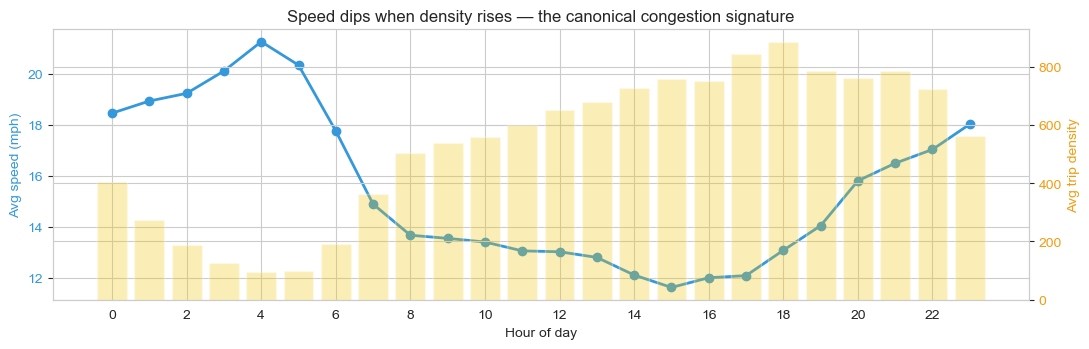

In [47]:
# Hourly trend — avg speed (line) vs trip density (bars)
hourly = df_labeled.groupby("hour_of_day").agg(
    avg_speed=("avg_speed_mph", "mean"),
    density=("trip_density", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 3.6))
ax1.plot(hourly["hour_of_day"], hourly["avg_speed"], "o-",
         color="#3498db", linewidth=2, markersize=6, label="avg speed")
ax1.set_xlabel("Hour of day"); ax1.set_ylabel("Avg speed (mph)", color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")
ax2 = ax1.twinx()
ax2.bar(hourly["hour_of_day"], hourly["density"], alpha=0.3, color="#f1c40f")
ax2.set_ylabel("Avg trip density", color="#f39c12")
ax2.tick_params(axis="y", labelcolor="#f39c12")
ax1.set_xticks(range(0, 24, 2))
plt.title("Speed dips when density rises — the canonical congestion signature")
plt.tight_layout(); plt.show()


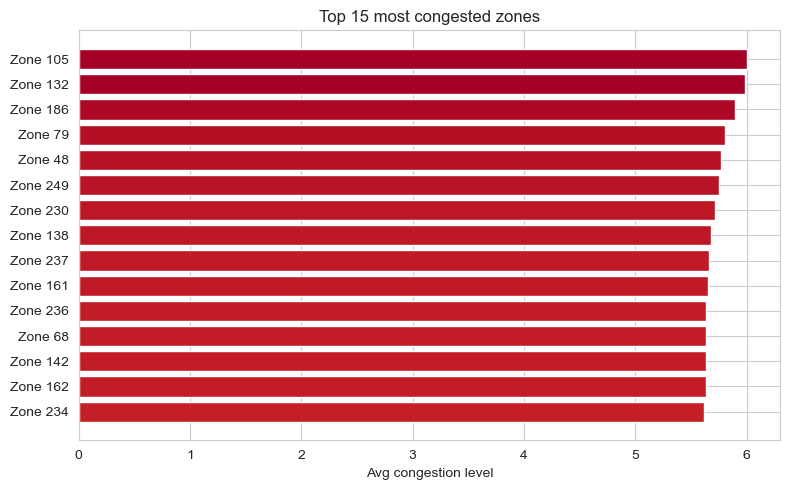

In [48]:
# Top-15 most congested zones (dataset-wide)
top = (df_labeled.groupby("zone_id")["congestion_level"]
                 .mean().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"Zone {int(z)}" for z in top.index][::-1], top.values[::-1],
        color=plt.cm.RdYlGn_r(top.values[::-1] / max(top.values.max(), 1e-9)))
ax.set_xlabel("Avg congestion level")
ax.set_title("Top 15 most congested zones")
plt.tight_layout(); plt.show()


In [49]:
def run_dbscan(X_scaled, df, eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES):
    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(X_scaled)
    n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))
    n_noise    = int((labels == -1).sum())
    noise_frac = n_noise / len(labels) if len(labels) else float("nan")
    if n_clusters > 0:
        sizes = pd.Series(labels[labels != -1]).value_counts()
        size_stats = {"min": int(sizes.min()), "median": float(sizes.median()),
                      "max": int(sizes.max()), "largest_label": int(sizes.idxmax())}
    else:
        size_stats = {"min": 0, "median": 0, "max": 0, "largest_label": -1}
    df = df.copy()
    df["dbscan_label"] = labels.astype("int16")
    return df, {"n_hotspots": n_clusters, "n_noise": n_noise,
                "noise_fraction": round(noise_frac, 4),
                "noise_warn": noise_frac > DBSCAN_NOISE_WARN_FRACTION,
                **size_stats}

df_dbscan, dbscan_metrics = run_dbscan(X_scaled, df_labeled)
print("DBSCAN:")
for k_, v in dbscan_metrics.items():
    print(f"  {k_}: {v}")


DBSCAN:
  n_hotspots: 3
  n_noise: 377
  noise_fraction: 0.0096
  noise_warn: False
  min: 11
  median: 11229.0
  max: 27796
  largest_label: 0
